In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [3]:
!pip install -q monai nibabel einops scikit-learn kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 50.9 MB/s eta 0:00:00


In [4]:
from google.colab import files
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle*.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

Saving kaggle (1).json to kaggle (1).json


In [5]:
!kaggle datasets download -d awsaf49/brats20-dataset-training-validation

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
100% 4.16G/4.16G [01:05<00:00, 79.2MB/s]
100% 4.16G/4.16G [01:05<00:00, 68.3MB/s]


In [6]:
!unzip -q brats20-dataset-training-validation.zip "BraTS2020_TrainingData/*" -d /content/brats
!rm brats20-dataset-training-validation.zip

In [7]:
import os
import torch
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, Spacingd, ScaleIntensityd,
    CropForegroundd, SpatialPadd,
    RandSpatialCropd, EnsureTyped,
    AsDiscrete, MapTransform
)

from monai.data import CacheDataset, DataLoader
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [9]:
class ConvertLabels(MapTransform):
    def __call__(self, data):
        d = dict(data)
        label = d["label"]
        label[label == 4] = 3
        d["label"] = label
        return d

In [10]:
data_dir = "/content/brats/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

patients = sorted(glob(os.path.join(data_dir, "*")))
print("Patients:", len(patients))

Patients: 371


In [11]:
data_dicts = []

for patient in patients:
    flair = glob(os.path.join(patient, "*_flair.nii*"))
    t1 = glob(os.path.join(patient, "*_t1.nii*"))
    t1ce = glob(os.path.join(patient, "*_t1ce.nii*"))
    t2 = glob(os.path.join(patient, "*_t2.nii*"))
    seg = glob(os.path.join(patient, "*_seg.nii*"))

    if len(flair)==0 or len(t1)==0 or len(t1ce)==0 or len(t2)==0 or len(seg)==0:
        continue

    data_dicts.append({
        "image": [flair[0], t1[0], t1ce[0], t2[0]],
        "label": seg[0]
    })

print("Final dataset size:", len(data_dicts))

Final dataset size: 368


In [12]:
train_files, val_files = train_test_split(
    data_dicts,
    test_size=0.2,
    random_state=42
)

In [13]:
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ConvertLabels(keys=["label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"],
             pixdim=(1.5,1.5,2.0),
             mode=("bilinear","nearest")),
    ScaleIntensityd(keys="image"),
    CropForegroundd(keys=["image","label"], source_key="image"),
    SpatialPadd(keys=["image","label"], spatial_size=(64,64,64)),
    RandSpatialCropd(keys=["image","label"],
                     roi_size=(64,64,64),
                     random_size=False),
    EnsureTyped(keys=["image","label"])
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ConvertLabels(keys=["label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"],
             pixdim=(1.5,1.5,2.0),
             mode=("bilinear","nearest")),
    ScaleIntensityd(keys="image"),
    CropForegroundd(keys=["image","label"], source_key="image"),
    SpatialPadd(keys=["image","label"], spatial_size=(64,64,64)),
    EnsureTyped(keys=["image","label"])
])

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [14]:
train_ds = CacheDataset(train_files, train_transforms,
                        cache_rate=0.0,
                        num_workers=1)

val_ds = CacheDataset(val_files, val_transforms,
                      cache_rate=0.0,
                      num_workers=1)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1)

In [15]:
model = SwinUNETR(
    in_channels=4,
    out_channels=4,
    feature_size=24
).to(device)

In [16]:
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipython-input-1105/3728953501.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [17]:
post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

dice_metric = DiceMetric(include_background=False, reduction="mean")

In [18]:
model.eval()

with torch.no_grad():
    val_data = next(iter(val_loader))

    val_inputs = val_data["image"].to(device)
    val_labels = val_data["label"].to(device)

    val_outputs = sliding_window_inference(
        val_inputs,
        roi_size=(96,96,96),
        sw_batch_size=1,
        predictor=model,
        overlap=0.5
    )

    # Convert logits → predicted labels
    val_outputs = torch.argmax(val_outputs, dim=1)

    print("Unique predicted classes:",
          torch.unique(val_outputs))

    print("Unique ground truth classes:",
          torch.unique(val_labels))

/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out[idx_zm] += p


Unique predicted classes: metatensor([0, 1, 2, 3], device='cuda:0')
Unique ground truth classes: metatensor([0., 1., 2., 3.], device='cuda:0')


In [19]:
# Use per-class raw Dice values
dice_metric = DiceMetric(
    include_background=False,
    reduction="none"
)

max_epochs = 15
val_interval = 2

best_metric = -1
best_metric_epoch = -1

for epoch in range(max_epochs):

    print("=" * 60)
    print(f"Epoch {epoch+1}/{max_epochs}")

    # ======================
    # TRAINING
    # ======================
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        inputs = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(inputs)
            loss = loss_function(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    print(f"Training Loss: {epoch_loss:.4f}")

    # ======================
    # VALIDATION
    # ======================
    if (epoch + 1) % val_interval == 0:

        model.eval()
        dice_metric.reset()

        with torch.no_grad():
            for val_data in val_loader:

                val_inputs = val_data["image"].to(device)
                val_labels = val_data["label"].to(device)

                val_outputs = sliding_window_inference(
                    val_inputs,
                    roi_size=(96,96,96),
                    sw_batch_size=1,
                    predictor=model,
                    overlap=0.5
                )

                # Convert to discrete predictions
                val_outputs = torch.argmax(val_outputs, dim=1, keepdim=True)

                dice_metric(val_outputs, val_labels)

        # Aggregate safely
        metric = dice_metric.aggregate()
        mean_dice = metric.mean().item()
        dice_metric.reset()

        print(f"Validation Mean Dice: {mean_dice:.4f}")

        # Save best model
        if mean_dice > best_metric:
            best_metric = mean_dice
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(), "best_model.pth")
            print("Saved best model")

print("=" * 60)
print("Training complete")
print(f"Best Mean Dice: {best_metric:.4f} at epoch {best_metric_epoch}")

Epoch 1/15
Training Loss: 1.4242
Epoch 2/15
Training Loss: 1.0152
Validation Mean Dice: 0.1666
Saved best model
Epoch 3/15
Training Loss: 0.8440
Epoch 4/15
Training Loss: 0.7280
Validation Mean Dice: 0.3673
Saved best model
Epoch 5/15
Training Loss: 0.6578
Epoch 6/15
Training Loss: 0.5991
Validation Mean Dice: 0.3908
Saved best model
Epoch 7/15
Training Loss: 0.5630
Epoch 8/15
Training Loss: 0.5275
Validation Mean Dice: 0.3992
Saved best model
Epoch 9/15
Training Loss: 0.5021
Epoch 10/15
Training Loss: 0.4815
Validation Mean Dice: 0.3980
Epoch 11/15
Training Loss: 0.4604
Epoch 12/15
Training Loss: 0.4469
Validation Mean Dice: 0.4244
Saved best model
Epoch 13/15
Training Loss: 0.4414
Epoch 14/15
Training Loss: 0.4332
Validation Mean Dice: 0.4196
Epoch 15/15
Training Loss: 0.4263
Training complete
Best Mean Dice: 0.4244 at epoch 12


In [20]:
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()
print('Best model loaded (epoch 12, Mean Dice: 0.4244)')

Best model loaded (epoch 12, Mean Dice: 0.4244)


In [21]:
dice_metric_eval = DiceMetric(
    include_background=False,
    reduction='mean_batch'   # returns per-class scores
)

post_pred_eval  = AsDiscrete(argmax=True,  to_onehot=4)
post_label_eval = AsDiscrete(to_onehot=4)

model.eval()
print('Running full validation set evaluation...')

with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        val_inputs = val_data['image'].to(device)
        val_labels = val_data['label'].to(device)

        val_outputs = sliding_window_inference(
            val_inputs,
            roi_size=(96, 96, 96),
            sw_batch_size=1,
            predictor=model,
            overlap=0.5
        )

        val_outputs_post = [post_pred_eval(o) for o in val_outputs]
        val_labels_post  = [post_label_eval(l) for l in val_labels]

        dice_metric_eval(
            y_pred=torch.stack(val_outputs_post),
            y=torch.stack(val_labels_post)
        )

        if (i + 1) % 10 == 0:
            print(f'  Processed {i+1}/{len(val_loader)} cases...')

# Aggregate
per_class_dice = dice_metric_eval.aggregate()   # shape: [3] for classes 1,2,3
dice_metric_eval.reset()

class_names = ['NCR/NET (Class 1)', 'Edema (Class 2)', 'ET (Class 3)']
mean_dice_final = per_class_dice.mean().item()

print('\n' + '=' * 55)
print('   FINAL VALIDATION RESULTS — SwinUNETR BraTS2020')
print('=' * 55)
for name, score in zip(class_names, per_class_dice):
    print(f'  {name:<22}: {score.item():.4f}')
print('-' * 55)
print(f'  Mean Dice (foreground) : {mean_dice_final:.4f}')
print('=' * 55)

Running full validation set evaluation...
  Processed 10/74 cases...
  Processed 20/74 cases...
  Processed 30/74 cases...
  Processed 40/74 cases...
  Processed 50/74 cases...
  Processed 60/74 cases...
  Processed 70/74 cases...

   FINAL VALIDATION RESULTS — SwinUNETR BraTS2020
  NCR/NET (Class 1)     : 0.4244
  Edema (Class 2)       : 0.4338
  ET (Class 3)          : 0.5239
-------------------------------------------------------
  Mean Dice (foreground) : 0.4607


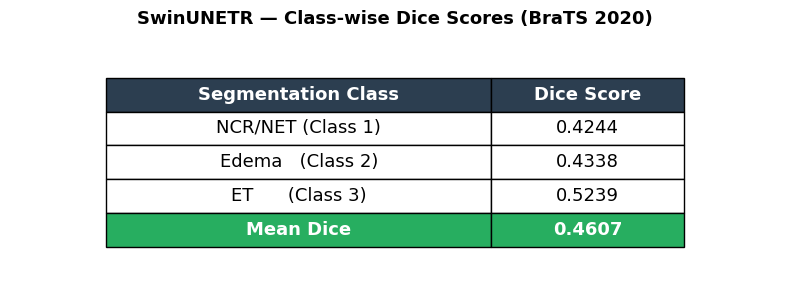

 Saved: dice_table.png


In [23]:
import matplotlib.pyplot as plt
import os

RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

class_scores = [s.item() for s in per_class_dice]

table_data = [
    ['NCR/NET (Class 1)', f'{class_scores[0]:.4f}'],
    ['Edema   (Class 2)', f'{class_scores[1]:.4f}'],
    ['ET      (Class 3)', f'{class_scores[2]:.4f}'],
    ['Mean Dice', f'{mean_dice_final:.4f}'],
]

col_labels = ['Segmentation Class', 'Dice Score']
tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=[0.5, 0.25]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.scale(1, 2)

# Style header row
for j in range(2):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Highlight mean row
for j in range(2):
    tbl[4, j].set_facecolor('#27ae60')
    tbl[4, j].set_text_props(color='white', fontweight='bold')

plt.title('SwinUNETR — Class-wise Dice Scores (BraTS 2020)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dice_table.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: dice_table.png')

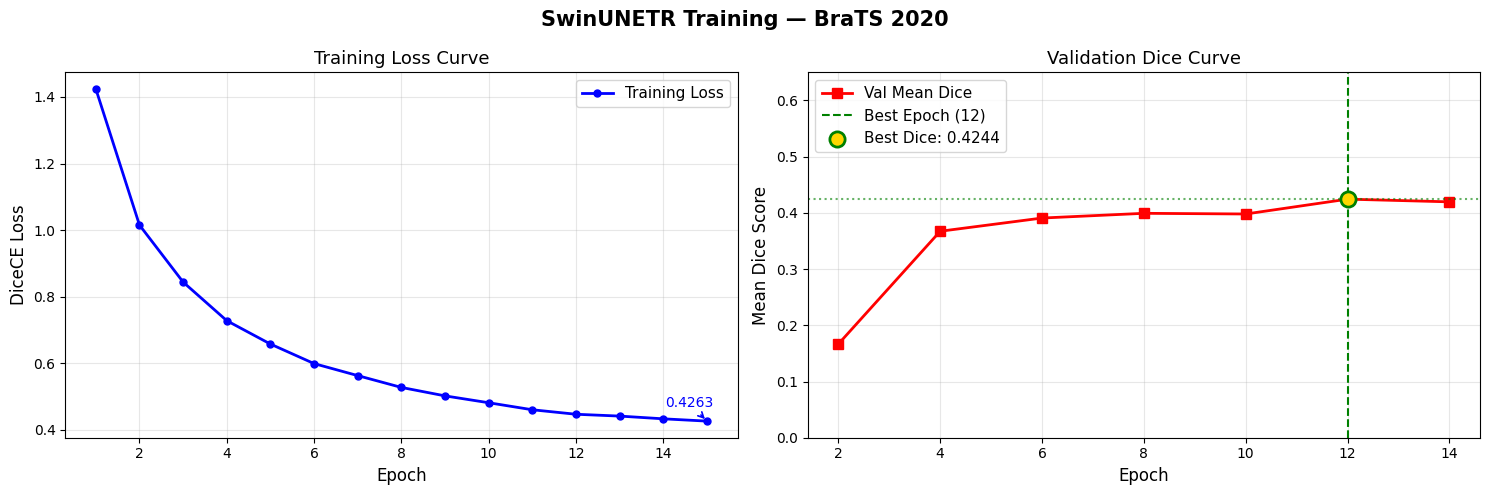

Saved: training_curves.png


In [24]:
train_loss_history = [
    1.4242, 1.0152, 0.8440, 0.7280, 0.6578,
    0.5991, 0.5630, 0.5275, 0.5021, 0.4815,
    0.4604, 0.4469, 0.4414, 0.4332, 0.4263
]
val_dice_epochs = [2, 4, 6, 8, 10, 12, 14]
val_dice_scores = [0.1666, 0.3673, 0.3908, 0.3992, 0.3980, 0.4244, 0.4196]
best_epoch      = 12
best_dice_val   = 0.4244
# -----------------------------------------------------------------

epochs = list(range(1, len(train_loss_history) + 1))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('SwinUNETR Training — BraTS 2020', fontsize=15, fontweight='bold')

# --- Loss curve ---
ax1 = axes[0]
ax1.plot(epochs, train_loss_history, 'b-o', markersize=5, linewidth=2, label='Training Loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('DiceCE Loss', fontsize=12)
ax1.set_title('Training Loss Curve', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Annotate final value
ax1.annotate(f'{train_loss_history[-1]:.4f}',
             xy=(epochs[-1], train_loss_history[-1]),
             xytext=(-30, 10), textcoords='offset points',
             fontsize=10, color='blue',
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.2))

# --- Dice curve ---
ax2 = axes[1]
ax2.plot(val_dice_epochs, val_dice_scores, 'r-s', markersize=7, linewidth=2, label='Val Mean Dice')
ax2.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.5, label=f'Best Epoch ({best_epoch})')
ax2.axhline(y=best_dice_val, color='green', linestyle=':', linewidth=1.5, alpha=0.6)
ax2.scatter([best_epoch], [best_dice_val], color='gold', s=120, zorder=5,
            edgecolors='green', linewidths=2, label=f'Best Dice: {best_dice_val:.4f}')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Mean Dice Score', fontsize=12)
ax2.set_title('Validation Dice Curve', fontsize=13)
ax2.set_ylim(0, 0.65)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out[idx_zm] += p


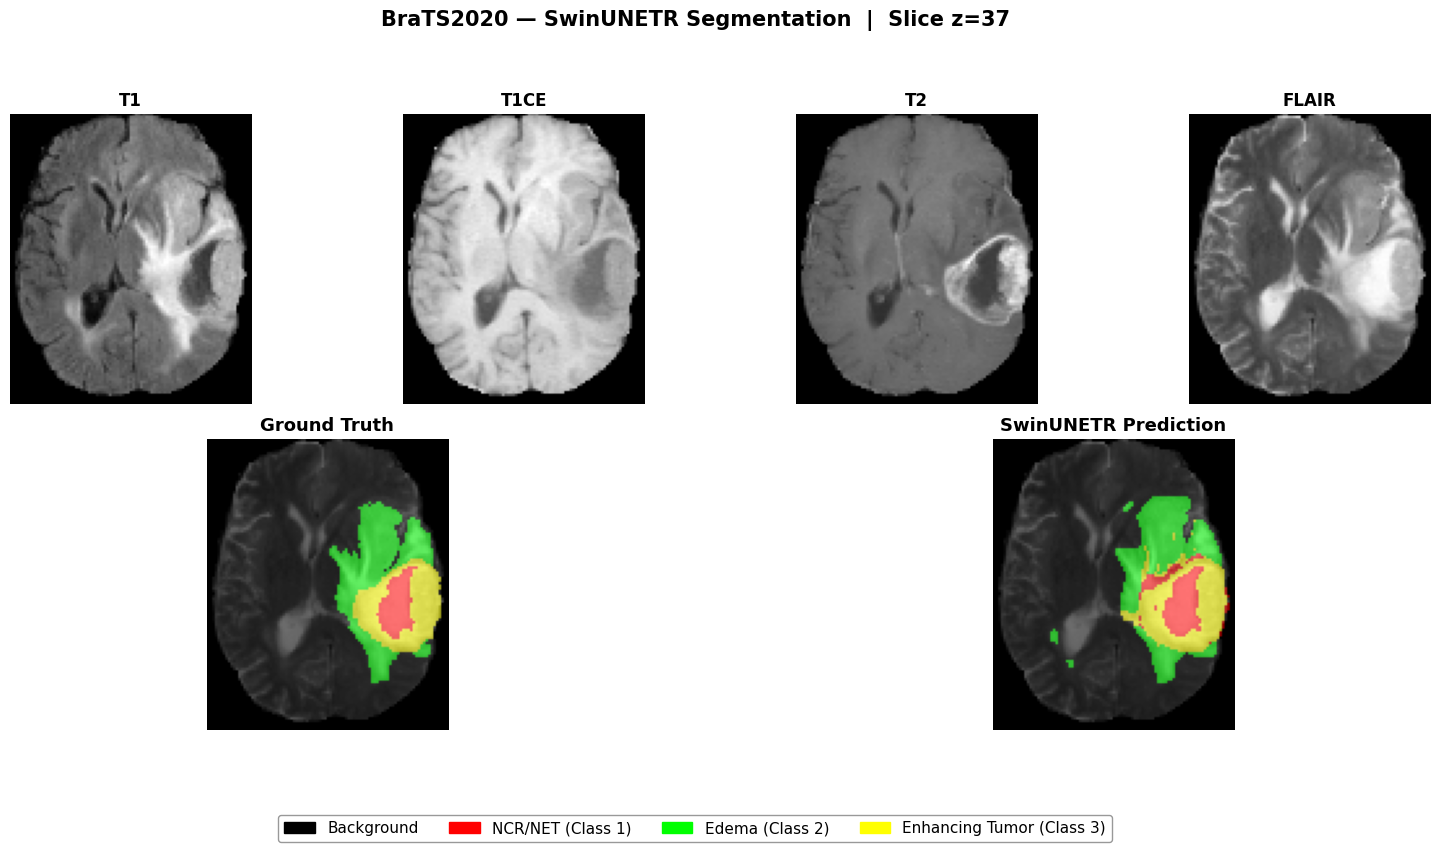

 Saved: visual_comparison.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors # Import mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import os

seg_cmap = mcolors.ListedColormap(['black', 'red', 'lime', 'yellow'])

model.eval()
with torch.no_grad():
    sample = next(iter(val_loader))
    inputs = sample['image'].to(device)   # (1, 4, H, W, D)
    labels = sample['label'].to(device)   # (1, 1, H, W, D)

    outputs = sliding_window_inference(
        inputs, roi_size=(96, 96, 96),
        sw_batch_size=1, predictor=model, overlap=0.5
    )
    preds = torch.argmax(outputs, dim=1, keepdim=True)  # (1, 1, H, W, D)

# CPU & numpy
inp_np   = inputs[0].cpu().numpy()        # (4, H, W, D)
gt_np    = labels[0, 0].cpu().numpy()     # (H, W, D)
pred_np  = preds[0, 0].cpu().numpy()      # (H, W, D)

# Pick the slice with the most segmentation
tumor_per_slice = (gt_np > 0).sum(axis=(0, 1))
best_z = int(np.argmax(tumor_per_slice))

modality_names = ['T1', 'T1CE', 'T2', 'FLAIR']

fig = plt.figure(figsize=(20, 8))
fig.suptitle(f'BraTS2020 — SwinUNETR Segmentation  |  Slice z={best_z}',
             fontsize=15, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 4, hspace=0.12, wspace=0.06)

# Row 1: 4 MRI modalities
for i in range(4):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(inp_np[i, :, :, best_z].T, cmap='gray', origin='lower')
    ax.set_title(modality_names[i], fontsize=12, fontweight='bold')
    ax.axis('off')

# Row 2 left: GT overlay on FLAIR
ax_gt = fig.add_subplot(gs[1, 0:2])
ax_gt.imshow(inp_np[3, :, :, best_z].T, cmap='gray', origin='lower')
ax_gt.imshow(gt_np[:, :, best_z].T, cmap=seg_cmap, alpha=0.55,
             vmin=0, vmax=3, origin='lower')
ax_gt.set_title('Ground Truth', fontsize=13, fontweight='bold')
ax_gt.axis('off')

# Row 2 right: Prediction overlay on FLAIR
ax_pred = fig.add_subplot(gs[1, 2:4])
ax_pred.imshow(inp_np[3, :, :, best_z].T, cmap='gray', origin='lower')
ax_pred.imshow(pred_np[:, :, best_z].T, cmap=seg_cmap, alpha=0.55,
               vmin=0, vmax=3, origin='lower')
ax_pred.set_title('SwinUNETR Prediction', fontsize=13, fontweight='bold')
ax_pred.axis('off')

# Legend
legend_patches = [
    mpatches.Patch(color='black',  label='Background'),
    mpatches.Patch(color='red',    label='NCR/NET (Class 1)'),
    mpatches.Patch(color='lime',   label='Edema (Class 2)'),
    mpatches.Patch(color='yellow', label='Enhancing Tumor (Class 3)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.04),
           fancybox=True, edgecolor='gray')

plt.savefig(os.path.join(RESULTS_DIR, 'visual_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: visual_comparison.png')

Generating GIF from 35 slices...
 Saved GIF: ./results/segmentation_scroll.gif


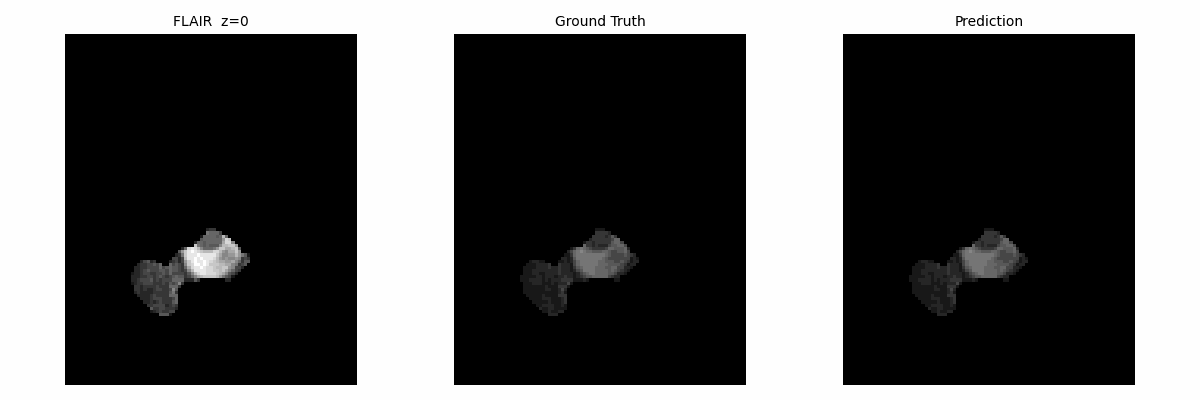

In [37]:
import imageio
from IPython.display import display, Image as IPImage

gif_path = os.path.join(RESULTS_DIR, 'segmentation_scroll.gif')
frames   = []

# Only render slices where there is some content
active_slices = [z for z in range(0, gt_np.shape[2], 2)
                 if inp_np[3, :, :, z].max() > 0]

print(f'Generating GIF from {len(active_slices)} slices...')

for z in active_slices:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(inp_np[3, :, :, z].T, cmap='gray', origin='lower')
    axes[0].set_title(f'FLAIR  z={z}', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(inp_np[3, :, :, z].T, cmap='gray', origin='lower')
    axes[1].imshow(gt_np[:, :, z].T, cmap=seg_cmap, alpha=0.5, vmin=0, vmax=3, origin='lower')
    axes[1].set_title('Ground Truth', fontsize=10)
    axes[1].axis('off')

    axes[2].imshow(inp_np[3, :, :, z].T, cmap='gray', origin='lower')
    axes[2].imshow(pred_np[:, :, z].T, cmap=seg_cmap, alpha=0.5, vmin=0, vmax=3, origin='lower')
    axes[2].set_title('Prediction', fontsize=10)
    axes[2].axis('off')

    plt.tight_layout()
    fig.canvas.draw()
    frame_arr = np.asarray(fig.canvas.buffer_rgba())
    frames.append(frame_arr)
    plt.close(fig)

imageio.mimsave(gif_path, frames, fps=6)
print(f' Saved GIF: {gif_path}')
display(IPImage(filename=gif_path, width=700))

In [30]:
from monai.networks.nets import UNet
from monai.networks.layers import Norm

unet_model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)

unet_params = sum(p.numel() for p in unet_model.parameters())
swin_params = sum(p.numel() for p in model.parameters())

print('3D U-Net Architecture:')
print(f'  Parameters: {unet_params:,}')
print()
print('SwinUNETR Architecture:')
print(f'  Parameters: {swin_params:,}')

3D U-Net Architecture:
  Parameters: 4,813,569

SwinUNETR Architecture:
  Parameters: 15,705,646


In [33]:
import shutil

PROJECT_DIR = '/content/brats_swinunetr'

dirs = [
    f'{PROJECT_DIR}/src',
    f'{PROJECT_DIR}/results',
    f'{PROJECT_DIR}/checkpoints',
]
for d in dirs:
    os.makedirs(d, exist_ok=True)

# Copy result images
for fname in ['training_curves.png', 'visual_comparison.png',
              'dice_table.png', 'model_comparison.png']:
    src = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, f'{PROJECT_DIR}/results/{fname}')

# Copy model checkpoint
if os.path.exists('best_model.pth'):
    shutil.copy('best_model.pth', f'{PROJECT_DIR}/checkpoints/swinunetr_best.pth')
if os.path.exists('best_unet_model.pth'):
    shutil.copy('best_unet_model.pth', f'{PROJECT_DIR}/checkpoints/unet_best.pth')

print(' Folder structure created:')
for root, subdirs, files in os.walk(PROJECT_DIR):
    level = root.replace(PROJECT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        print(f'{indent}  {f}')

 Folder structure created:
brats_swinunetr/
  src/
  checkpoints/
    swinunetr_best.pth
  results/
    visual_comparison.png
    dice_table.png
    training_curves.png


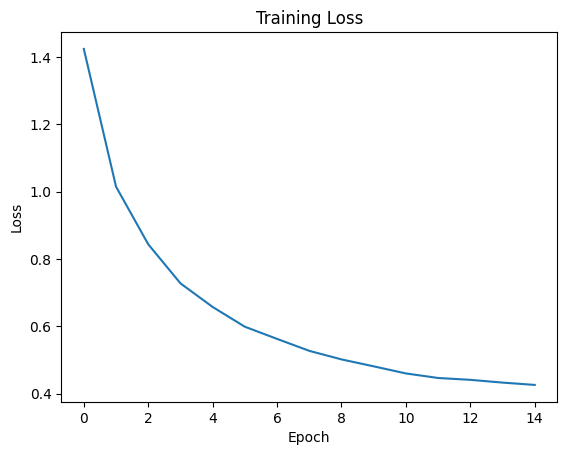

In [39]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("training_curve.png")
plt.show()

In [40]:
import imageio


imageio.mimsave("prediction.gif", frames, fps=2)